# The company that couldn't hand in its homework 📝
### When a firm files an *NT 10-K* ("we can't file our annual report on time"), is that a sell signal?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Second NT the kill signal?: Busted](https://img.shields.io/badge/Second_NT_the_kill_signal%3F-Busted-8b949e?style=flat-square)

Every listed US company has a legal deadline to publish its annual report (the 10-K) and its quarterly reports (10-Qs). Miss the deadline and you must file a confession with the SEC — **Form 12b-25**, which shows up on EDGAR as **"NT 10-K"** or **"NT 10-Q"** (*NT* = notification of late filing). It buys a few extra days, and it tells the whole market: *something inside our accounting broke*.

The folk rule says the NT is a **sell signal** — audits don't get delayed for good news. We pulled **every NT filing on EDGAR since 2004** (102,505 of them!), matched them to stock prices, and measured what happens in the **60 trading days after** the confession.

> 📓 Want the *t*-stats, the calendar-time portfolio and the placebos? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **The one warning that changes everything.** We can only price companies that still have a ticker **today** — barely **1 NT filing in 5** does. The very worst late filers (frauds, bankruptcies) got **delisted** and vanish from the panel. So whatever we measure is the NT effect on the *survivors* — its mildest corner. Keep that in mind for every chart below.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from late_filers import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    EVENTS, PRICES = data.load_real()
    CARS = st.build_event_cars(EVENTS, PRICES)
else:
    EVENTS = PRICES = CARS = None
print("real NT cache present:", HAVE_REAL,
      "| usable events:", (0 if CARS is None else len(CARS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'nt_total': 102505, 'ntk': 37502, 'ntq': 65003, 'in_window': 89497, 'mapped': 17199, 'mapped_pct': 19.2, 'events': 1993, 'tickers': 421, 'usable': 1180, 'use_ntk': 494, 'use_ntq': 686, 'use_repeat': 822, 'px_days': 5807, 'px_names': 422, 'px_start': '2003-06-02', 'px_end': '2026-06-30', 'as_of': '2026-06-30', 'fp_events': '82ef3cc79145', 'fp_spy': '860d1267b8a2', 'reaction_bps': -33.0, 't_reaction': -0.99, 'car_bps': -105.7, 't_naive': -0.71, 'ct_bps_day': 3.39, 'ct_hac_t': 0.83, 'ct_ann': 8.9, 'ct_days': 5623, 'ct_avg_names': 12.6, 'pseudo_bps': 81.9, 'pseudo_n': 714, 'welch_vs_pseudo': -0.77, 'placebo_bps': 381.2, 'placebo_std': 147.1, 'placebo_seeds': 25, 'ntk_car': -205.1, 'ntk_t': -0.89, 'ntk_n': 494, 'ntk_hac': 0.52, 'ntq_car': -34.2, 'ntq_t': -0.17, 'ntq_n': 686, 'ntq_hac': 0.66, 'rep_car': 58.0, 'rep_n': 822, 'rep_hac': 1.18, 'fst_car': -481.7, 'fst_n': 358, 'fst_hac': -0.59, 'rep_minus_fst': 539.7, 'welch_rep': 1.85, 'robust': [(20, -146.4, -0.96), (40, -5.5, 0.06), (60, -105.7, 0.83)], 'costs': [(10.0, 3.0, 14.3), (10.0, 10.0, -152.4), (20.0, 3.0, -5.7), (20.0, 10.0, -172.4)], 'syn': [(0.0, 90.6, 0.94, 0.55), (-20.0, -1152.3, -11.93, -10.42)]}


real NT cache present: True | usable events: 1180


## The answer first

| Question | Answer |
|---|---|
| Does the stock keep falling after the NT? | On the *survivors* we can measure: **not measurably**. About **-1.1%** vs the market over ~3 months — statistically indistinguishable from zero. |
| So the folk rule is dead? | Not quite. The academic studies (with point-in-time data that includes the later-delisted names) DO find a real drop. Our survivors-only tape simply **can't certify it** — and it's biased toward finding nothing. |
| Can you make money shorting NT filers? | **No.** Even granting the (uncertified) drift, borrow fees and spreads eat it; the names you'd most want to short are the hardest to borrow — or already delisted. |
| Is the SECOND NT in a row the real kill signal? | **Busted.** Repeat offenders drift *milder* than first-timers. Chronic lateness gets priced as routine. |

## What an NT filing looks like on the tape

The chart tracks the average path of a late filer's stock **relative to the market (SPY)** from the filing day forward. Day 0 is the confession; anything before the next day's close is untradable (filings often land at 9 pm).

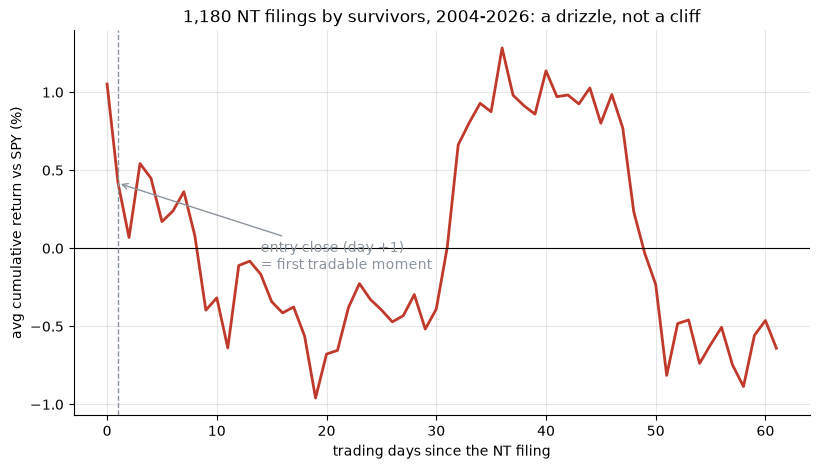

In [2]:
if HAVE_REAL:
    # average cumulative market-adjusted path, day 0 .. +60 trading days
    rets = PRICES.pct_change(); mkt = rets['SPY'].to_numpy()
    paths = []
    for ev in CARS.itertuples(index=False):
        r = rets[ev.ticker].to_numpy()
        d0 = ev.pos - st.LAG
        seg = r[d0: d0 + 62] - mkt[d0: d0 + 62]
        if len(seg) == 62 and np.isfinite(seg).sum() >= 50:
            paths.append(np.nancumsum(np.where(np.isfinite(seg), seg, 0)))
    avg = np.mean(paths, axis=0) * 100
    fig, ax = plt.subplots()
    ax.plot(range(62), avg, color=RED, lw=2)
    ax.axhline(0, color='k', lw=.8)
    ax.axvline(st.LAG, color=GREY, ls='--', lw=1)
    ax.annotate('entry close (day +1)\n= first tradable moment', xy=(st.LAG, avg[st.LAG]),
                xytext=(14, avg[st.LAG] - .55), color=GREY,
                arrowprops=dict(arrowstyle='->', color=GREY))
    ax.set_xlabel('trading days since the NT filing')
    ax.set_ylabel('avg cumulative return vs SPY (%)')
    ax.set_title(f'{len(paths):,} NT filings by survivors, 2004-2026: a drizzle, not a cliff')
    plt.show()
else:
    print('cache missing - the frozen numbers in R tell the story')

> 💡 **How to read it.** There's a small dip, but on ~1,200 events it never separates from noise — these are wildly volatile small caps, and the average hides swings of ±80% per name. No statistician would sign off on this line as a "signal".

## Why we still don't call the folk rule *false*

Three facts sit together:

1. **Our panel is the survivors.** Only 19.2% of NT filings map to a stock that still trades today. Firms whose NT preceded fraud revelations or bankruptcy — the cases the folk rule is *about* — ended delisted and can't be priced here.
2. **Published studies with point-in-time data** (Griffin 2003; Bartov, DeFond & Konchitchki; Duarte-Silva et al. 2013) find genuinely negative returns after late-filing announcements, continuing for weeks.
3. **On random days, our surviving names drift UP** vs the market (that's what surviving looks like). Their NT windows sit ~5% *below* that personal baseline — the right direction, just not provable with this noise.

So the honest reading is: *the literature says real; our survivors-only tape can't certify it* — the desk stamps that **Weak**, never **Real**.

## Could you trade it anyway?

Suppose you granted the drift. A short seller pays the spread **twice** and pays **borrow fees** for three months — and NT filers are small, distressed, hard-to-borrow names where borrow runs 10%+/yr when it exists at all. The quants' cost table says the net edge is ~zero in the friendliest case and **negative** everywhere realistic. Add that the fattest short payoffs (stocks that went to zero) sit in delisted names you couldn't borrow — the *trade* is a mirage even where the *information* is real.

## The second confession

Folklore says: forgive the first NT (audits hiccup), run from the second. The tape says the opposite: repeat offenders drift +0.6% vs -4.8% for first offenses — the chronic laggards are *milder*, because by the third late quarter everyone expects it. Whatever information an NT carries is in the **first** one.

## The bottom line

A late filing genuinely is bad news — the accounting literature shows it with data we can't reconstruct for free. But on the survivors a free tape can see, the sell signal is **not certifiable**, and as a *trade* it's a mirage: costs, borrow and delisting sit exactly where the edge should be.

*Research & education, not investment advice. House style: [METHODOLOGY.md](../../../METHODOLOGY.md).*